In [1]:
import os, sys
_nb_cwd = os.getcwd()
if os.path.basename(_nb_cwd).lower() == 'novoboard':
    PROJECT_ROOT = os.path.dirname(_nb_cwd)
    NOVOBOARD_DIR = _nb_cwd
else:
    PROJECT_ROOT = _nb_cwd
    NOVOBOARD_DIR = next(
        (os.path.join(_nb_cwd, n) for n in ('novoboard', 'NovoBoard')
         if os.path.isdir(os.path.join(_nb_cwd, n))),
        os.path.join(_nb_cwd, 'novoboard'),
    )
sys.path.insert(0, NOVOBOARD_DIR)   # so `import config` finds the repo's config.py
os.chdir(PROJECT_ROOT)              # all paths below are relative to project root
print('Project root:', os.getcwd())

# import libraries
from __future__ import print_function


import os
import sys
import csv
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import random
from multiprocessing import Pool
import time


import matplotlib
from matplotlib import pyplot
%matplotlib inline
from matplotlib_venn import venn3

from Bio import SeqIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord



Project root: /home/nagendra/ub/dl/De-Novo-Peptide-Sequencing


In [2]:
# Decoy FDR calculation

def read_denovo(denovo_csv, selected_features=None):
    denovo_psm = pd.read_csv(denovo_csv, keep_default_na=False)
    denovo_psm['feature_id'] = denovo_psm.apply(lambda row: row['Source File'].split('.mgf')[0] + '.mgf' + '||' + str(row['Scan']), axis=1)
    if selected_features:
        denovo_psm['selected_features'] = denovo_psm.apply(lambda row: row['feature_id'] in selected_features, axis=1)
        denovo_psm = denovo_psm[denovo_psm['selected_features']]
    return denovo_psm

def calculate_FDR(target_csv, decoy_csv, engine_score, fdr_list, selected_features=None):
    
    print("target_csv =", target_csv)
    print("decoy_csv =", decoy_csv)
    target_psm = read_denovo(target_csv, selected_features)
    decoy_psm = read_denovo(decoy_csv, selected_features)
    print("len(target_psm) =", len(target_psm)); print("len(decoy_psm) =", len(decoy_psm))
    dfs = pd.concat([target_psm, decoy_psm], keys=['target', 'decoy']).reset_index().rename(columns={'level_0': 'spectrum'})
    dfs['is_target'] = dfs.apply(lambda row: row['spectrum']=='target', axis=1)

    # target-decoy competition
    dfs.sort_values(by=[engine_score, 'is_target'], ascending=[False, False], inplace=True)
    # 1-1 competition on each scan id
#     dfs_fdr = dfs.drop_duplicates(subset=['feature_id'])
    # competition on whole dataset
    dfs_fdr = dfs
    dfs_fdr['feature_id'] = dfs_fdr.apply(lambda x: x['feature_id'] if x['is_target'] else x['feature_id']+'||decoy', axis=1)
    print("len(dfs) =", len(dfs))
    print("len(dfs_fdr) =", len(dfs_fdr))
    print("sum(dfs_fdr['is_target']) =", sum(dfs_fdr['is_target']))
    
    # fdr estimation
    cumsum = range(1, len(dfs_fdr) + 1)
    cumsum_target = np.cumsum(np.array(dfs_fdr['is_target'].astype(int)))
    cumsum_decoy = cumsum - cumsum_target
    estimated_fdr = cumsum_decoy / cumsum_target
    dfs_fdr['estimated_fdr'] = estimated_fdr

    score_list = []
    count_list = []
    for fdr in fdr_list:
        fdr_index = np.flatnonzero(estimated_fdr <= fdr)
        fdr_index = fdr_index[-1] if len(fdr_index) > 0 else 0
        score_list.append(dfs_fdr.iloc[fdr_index][engine_score])
        count_list.append(fdr_index + 1)

    return dfs, dfs_fdr, score_list, count_list



target_csv = novoboard_in_merged/casanovo/target/wastewater/wastewater_Sample1.csv
decoy_csv = novoboard_in_merged/casanovo/decoy/wastewater/wastewater_Sample1.csv
len(target_psm) = 34635
len(decoy_psm) = 34638
len(dfs) = 69273
len(dfs_fdr) = 69273
sum(dfs_fdr['is_target']) = 34635

=== casanovo ===
  FDR <= 1%: score cutoff = 0.9084, accepted = 1050
  FDR <= 5%: score cutoff = 0.5569, accepted = 9332
  FDR <= 10%: score cutoff = 0.2545, accepted = 12130
target_csv = novoboard_in_merged/instanovo/target/wastewater/wastewater_Sample1.csv
decoy_csv = novoboard_in_merged/instanovo/decoy/wastewater/wastewater_Sample1.csv
len(target_psm) = 34700
len(decoy_psm) = 34700
len(dfs) = 69400
len(dfs_fdr) = 69400
sum(dfs_fdr['is_target']) = 34700

=== instanovo ===
  FDR <= 1%: score cutoff = -0.0327, accepted = 4652
  FDR <= 5%: score cutoff = -0.7429, accepted = 12622
  FDR <= 10%: score cutoff = -1.7900, accepted = 16021
target_csv = novoboard_in_merged/instanovoplus/target/wastewater/wastewater

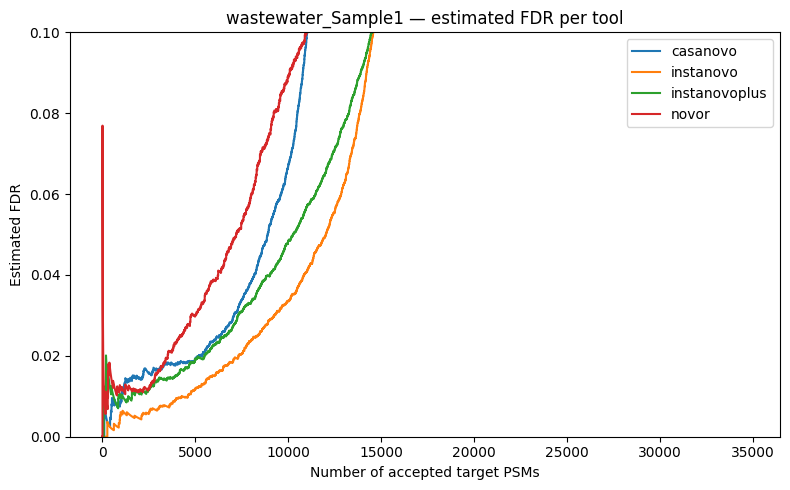

In [3]:
# Section 3 — estimated FDR per tool (wastewater_Sample1, no GT)
import os
os.makedirs('novoboard_out/wastewater_Sample1', exist_ok=True)

fdr_levels = [0.01, 0.05, 0.10]
engine_score = 'Score'
tools = ['casanovo', 'instanovo', 'instanovoplus', 'novor']

fdr_results = {}
for tool in tools:
    target_csv = f'novoboard_in_merged/{tool}/target/wastewater/wastewater_Sample1.csv'
    decoy_csv = f'novoboard_in_merged/{tool}/decoy/wastewater/wastewater_Sample1.csv'
    dfs, dfs_fdr, score_list, count_list = calculate_FDR(
        target_csv, decoy_csv, engine_score, fdr_levels)
    fdr_results[tool] = (dfs_fdr, score_list, count_list)
    print(f'\n=== {tool} ===')
    for fdr, sc, ct in zip(fdr_levels, score_list, count_list):
        print(f'  FDR <= {fdr*100:.0f}%: score cutoff = {sc:.4f}, accepted = {ct}')
    dfs_fdr.to_csv(f'novoboard_out/wastewater_Sample1/{tool}.fdr.csv', index=False)

fig, ax = pyplot.subplots(figsize=(8, 5))
for tool, (dfs_fdr, _, _) in fdr_results.items():
    target_estfdr = dfs_fdr.loc[dfs_fdr['is_target'], 'estimated_fdr'].values
    ax.plot(range(1, len(target_estfdr) + 1), target_estfdr, label=tool)
ax.set_xlabel('Number of accepted target PSMs')
ax.set_ylabel('Estimated FDR')
ax.set_ylim(0, 0.10)
ax.legend()
ax.set_title('wastewater_Sample1 — estimated FDR per tool')
pyplot.tight_layout()
pyplot.savefig('novoboard_out/wastewater_Sample1/estimated_fdr.png', dpi=150)
pyplot.show()
